In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

In [7]:
dataset = pd.read_csv('breast_cancer_data.csv')

In [9]:
dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [11]:
dataset['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [13]:
dataset.shape

(569, 33)

In [15]:
dataset.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [17]:
dataset.drop('Unnamed: 32', axis=1, inplace=True)

In [19]:
dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [21]:
diag_dataset = dataset['diagnosis'].value_counts()

In [23]:
a = diag_dataset.index
b = diag_dataset.values

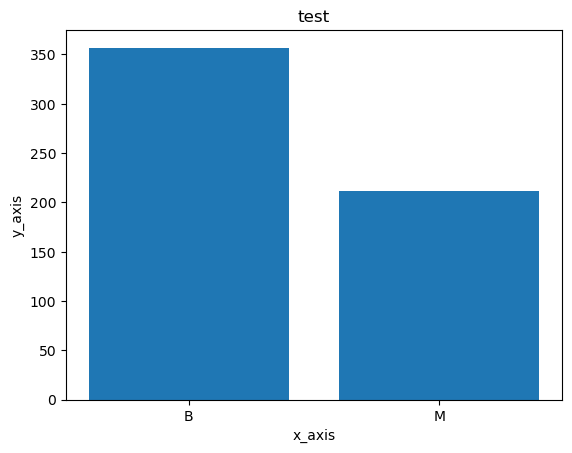

In [25]:
plt.bar(a, b)
plt.xlabel('x_axis')
plt.ylabel('y_axis')
plt.title('test')
plt.show()

In [27]:
dataset.replace({'M':1, 'B':0}, inplace=True)

C:\Users\MYPC\AppData\Local\Temp\ipykernel_25200\3268411250.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.replace({'M':1, 'B':0}, inplace=True)


In [29]:
dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [31]:
malig_data = dataset[dataset.diagnosis == 1] 
benign_data = dataset[dataset.diagnosis == 0]

In [33]:
malig_data.shape

(212, 32)

In [35]:
benign_data.shape

(357, 32)

In [37]:
# under sampling
benign_sample = benign_data.sample(n=212, random_state=1)
benign_sample

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
459,9112712,0,9.755,28.20,61.68,290.9,0.07984,0.04626,0.01541,0.010430,...,10.670,36.92,68.03,349.9,0.11100,0.1109,0.07190,0.04866,0.2321,0.07211
409,905501,0,12.270,17.92,78.41,466.1,0.08685,0.06526,0.03211,0.026530,...,14.100,28.88,89.00,610.2,0.12400,0.1795,0.13770,0.09532,0.3455,0.06896
539,921362,0,7.691,25.44,48.34,170.4,0.08668,0.11990,0.09252,0.013640,...,8.678,31.89,54.49,223.6,0.15960,0.3064,0.33930,0.05000,0.2790,0.10660
313,893988,0,11.540,10.72,73.73,409.1,0.08597,0.05969,0.01367,0.008907,...,12.340,12.87,81.23,467.8,0.10920,0.1626,0.08324,0.04715,0.3390,0.07434
524,917897,0,9.847,15.68,63.00,293.2,0.09492,0.08419,0.02330,0.024160,...,11.240,22.99,74.32,376.5,0.14190,0.2243,0.08434,0.06528,0.2502,0.09209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,914862,0,15.040,16.74,98.73,689.4,0.09883,0.13640,0.07721,0.061420,...,16.760,20.43,109.70,856.9,0.11350,0.2176,0.18560,0.10180,0.2177,0.08549
382,90250,0,12.050,22.72,78.75,447.8,0.06935,0.10730,0.07943,0.029780,...,12.570,28.71,87.36,488.4,0.08799,0.3214,0.29120,0.10920,0.2191,0.09349
458,9112594,0,13.000,25.13,82.61,520.2,0.08369,0.05073,0.01206,0.017620,...,14.340,31.88,91.06,628.5,0.12180,0.1093,0.04462,0.05921,0.2306,0.06291
136,868223,0,11.710,16.67,74.72,423.6,0.10510,0.06095,0.03592,0.026000,...,13.330,25.48,86.16,546.7,0.12710,0.1028,0.10460,0.06968,0.1712,0.07343


In [39]:
malig_data.shape

(212, 32)

In [41]:
benign_sample.shape

(212, 32)

In [43]:
new_dataset = pd.concat([malig_data, benign_sample], axis=0)

In [45]:
new_dataset['diagnosis'].value_counts()

diagnosis
1    212
0    212
Name: count, dtype: int64

In [47]:
new_dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [49]:
new_dataset.drop('id', inplace=True, axis=1)

In [51]:
new_dataset.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [53]:
x = new_dataset.drop('diagnosis', axis=1)
y = new_dataset['diagnosis']

In [55]:
print(x)
print(y)

     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
500        15.04         16.74           98.73      689.4          0.09883   
382        12.05         22.72           78.75      447.8          0.06935   
458        13.00         25.13           82.61      520.2          0.08369   
136        11.71         16.67           74.72      423.6          0.10510   
143        12.90         15.92           83.74      512.2          0.08677   

     compactness_mean  concavity_mean  concave points_mean  sym

In [57]:
object_type = new_dataset.select_dtypes(include=['object'])
print(object_type)

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 47, 53, 54, 56, 57, 62, 64, 65, 70, 72, 73, 75, 77, 78, 82, 83, 85, 86, 87, 91, 94, 95, 99, 100, 105, 108, 117, 118, 119, 121, 122, 126, 127, 129, 131, 132, 134, 135, 138, 141, 146, 156, 161, 162, 164, 167, 168, 171, 172, 177, 180, 181, 182, 184, 186, 190, 193, 194, ...]

[424 rows x 0 columns]


In [59]:
print(new_dataset.dtypes)

diagnosis                    int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst

In [61]:
new_dataset['diagnosis'] = new_dataset['diagnosis'].astype('float64')

In [63]:
new_dataset.dtypes

diagnosis                  float64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst

In [67]:
new_dataset.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1.0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1.0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1.0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1.0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [69]:
#split data
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [71]:
print(x.shape, X_train.shape, X_test.shape)

(424, 30) (339, 30) (85, 30)


In [73]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
print(X_train_scaled)

[[ 0.23088358  0.75068017  0.53272647 ...  1.78705747  0.56789003
   0.9856592 ]
 [ 0.35778803 -0.45140524  0.40700056 ...  0.89102591  2.16286329
   2.17749721]
 [ 1.184017   -0.8897597   1.16528498 ...  0.7606668  -0.77169477
  -1.20810244]
 ...
 [-0.63584681 -0.78356042 -0.5418372  ...  0.10887127  0.49400405
   1.06919925]
 [-0.27943431 -1.49306196 -0.33713969 ... -1.03259503 -0.16133239
  -0.90568747]
 [ 1.18131691  0.59025148  1.2124322  ...  0.65727855  0.43296782
   0.44599049]]


In [77]:
print(X_test_scaled)

[[-8.22153342e-01 -3.92656706e-01 -8.50258583e-01 ... -8.29114949e-01
  -1.51858558e+00 -8.38298499e-01]
 [-4.33339708e-01 -5.53085398e-01 -4.91546833e-01 ... -1.15726029e+00
  -2.51280534e-01 -6.80686277e-01]
 [ 8.77785647e-02  2.24424870e+00  2.71316708e-03 ... -9.16770210e-01
   4.97216488e-01 -1.25599874e+00]
 ...
 [ 1.02741151e+00  8.41102525e-02  1.00026972e+00 ...  3.30631589e-01
  -9.35528885e-01 -5.56490073e-01]
 [ 3.57788032e-01  1.81271291e-01  4.50218843e-01 ...  1.20418744e+00
   1.25695703e+00  1.67068759e+00]
 [-4.57640560e-01 -9.75622939e-01 -3.70535641e-01 ...  1.07382834e+00
   3.59081845e-01  3.13542308e+00]]


In [79]:
log_model = LogisticRegression()

In [81]:
log_model.fit(X_train_scaled, Y_train)

LogisticRegression()

In [83]:
X_train_pred = log_model.predict(X_train_scaled)

In [85]:
X_train_accuracy = accuracy_score(X_train_pred, Y_train)
X_train_precision = precision_score(X_train_pred, Y_train)
X_train_recall = recall_score(X_train_pred, Y_train)
X_train_report = classification_report(X_train_pred, Y_train)
print(X_train_accuracy)
print(X_train_precision)
print(X_train_recall)
print(X_train_report)

0.9911504424778761
0.9879518072289156
0.9939393939393939
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       174
           1       0.99      0.99      0.99       165

    accuracy                           0.99       339
   macro avg       0.99      0.99      0.99       339
weighted avg       0.99      0.99      0.99       339



In [87]:
X_test_pred = log_model.predict(X_test_scaled)

In [89]:
X_test_accuracy = accuracy_score(X_test_pred, Y_test)
X_test_precision = precision_score(X_test_pred, Y_test)
X_test_recall = recall_score(X_test_pred, Y_test)
X_test_report = classification_report(X_test_pred, Y_test)
print(X_test_accuracy)
print(X_test_precision)
print(X_test_recall)
print(X_test_report)

0.9529411764705882
0.9347826086956522
0.9772727272727273
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        41
           1       0.93      0.98      0.96        44

    accuracy                           0.95        85
   macro avg       0.95      0.95      0.95        85
weighted avg       0.95      0.95      0.95        85



In [91]:
import seaborn as sns

In [93]:
new_dataset.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1.0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1.0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1.0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1.0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [95]:
correlate = new_dataset.corr()

<Axes: >

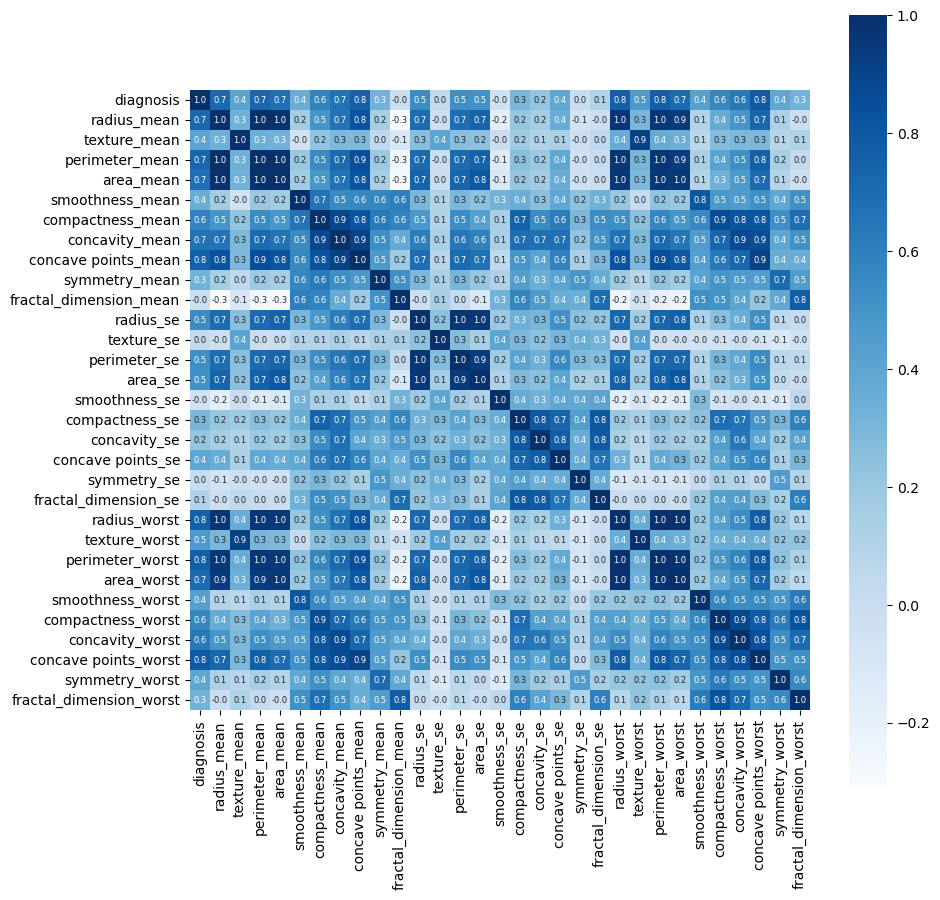

In [103]:
from __future__ import annotations
plt.figure(figsize=(10, 10))
sns.heatmap(correlate, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size': 6}, cmap='Blues')